https://github.com/lollcat/Soft-Actor-Critic/blob/master/SAC_Agent/Agent.py

In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [ ]:
from variable_print import p,ps,pst

In [ ]:
%%time
%%capture
!pip install swig
!pip install gymnasium[box2d] ## python 3.11은 gym[box2d]문제 있음
import gymnasium as gym  ###

CPU times: user 301 ms, sys: 38.2 ms, total: 340 ms
Wall time: 50.5 s


In [ ]:
import tensorflow as tf
import tensorflow_probability as tfp
import keras
from keras.layers import Dense, Flatten,Concatenate,BatchNormalization,Lambda
from keras.models import Model
from keras.optimizers import Adam

import numpy as np
import time
from collections import deque
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams["font.size"] = "8"
import warnings
warnings.filterwarnings("ignore")

#tf.keras.backend.set_floatx('float64')

# LunarLander_Continuous Environment

In [ ]:
# problem = "LunarLanderContinuous-v2"
# env = gym.make(problem,new_step_api=True)

env= gym.make("LunarLanderContinuous-v2")

num_states = env.observation_space.shape[0]      # 8
ps(env.observation_space,'Shape of State Space') #(8,)
p(env.observation_space,'env.observation_space')
print(f'state_low::{env.observation_space.low}')
print(f'state_high::{env.observation_space.high}\n')

num_actions = env.action_space.shape[0] # 2
ps(env.action_space,'Shape of Action Space') #(2,)
p(env.action_space,'env.action_space')
print(f'action_low::{env.action_space.low}')
print(f'action_high::{env.action_space.high}\n')

state = env.reset()
p(state,'state') #(8,)

<<Shape of State Space>> Shape(8,)
<<env.observation_space>>:
Shape:(8,)
Type: <class 'gym.spaces.box.Box'>
Values: Box([-1.5       -1.5       -5.        -5.        -3.1415927 -5.
 -0.        -0.       ], [1.5       1.5       5.        5.        3.1415927 5.        1.
 1.       ], (8,), float32)
state_low::[-1.5       -1.5       -5.        -5.        -3.1415927 -5.
 -0.        -0.       ]
state_high::[1.5       1.5       5.        5.        3.1415927 5.        1.
 1.       ]

<<Shape of Action Space>> Shape(2,)
<<env.action_space>>:
Shape:(2,)
Type: <class 'gym.spaces.box.Box'>
Values: Box(-1.0, 1.0, (2,), float32)
action_low::[-1. -1.]
action_high::[1. 1.]

<<state>>:
Shape:(8,)
Type: <class 'numpy.ndarray'>
Values: [-0.00493631  1.4088913  -0.50000477 -0.09017605  0.00572668  0.11325858
  0.          0.        ]


## Replay Buffer  

In [ ]:
class RBuffer():
  def __init__(self, maxsize=100, statedim=num_states, naction=num_actions):
    self.cnt = 0
    self.maxsize = maxsize
    self.state_memory = np.zeros((maxsize, statedim), dtype=np.float32)
    self.action_memory = np.zeros((maxsize, naction), dtype=np.float32)
    self.reward_memory = np.zeros((maxsize,), dtype=np.float32)
    self.next_state_memory = np.zeros((maxsize, statedim), dtype=np.float32)
    self.Ndone_memory = np.zeros((maxsize,), dtype=np.int32)

  def record(self, state, action, reward, next_state, done):
    index = self.cnt % self.maxsize
    self.state_memory[index] = state
    self.action_memory[index] = action
    self.reward_memory[index] = reward
    self.next_state_memory[index] = next_state
    self.Ndone_memory[index] = 1 - done
    self.cnt += 1

  def sample(self, batch_size):
    max_mem = min(self.cnt, self.maxsize)
    batch = np.random.choice(max_mem, batch_size, replace=False)
    states = tf.convert_to_tensor(self.state_memory[batch], dtype= tf.float32)
    actions = tf.convert_to_tensor(self.action_memory[batch], dtype= tf.float32)
    rewards = tf.convert_to_tensor(self.reward_memory[batch], dtype= tf.float32)
    next_states = tf.convert_to_tensor(self.next_state_memory[batch], dtype= tf.float32)
    Ndones = tf.convert_to_tensor(self.Ndone_memory[batch], tf.float32)
    return states, actions, rewards, next_states, Ndones

## Actor Net

Model: "functional_109"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_23            │ (None, 8)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_218 (Dense)         │ (None, 256)            │          2,304 │ input_layer_23[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_219 (Dense)         │ (None, 256)            │         65,792 │ dense_218[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ sigma (Dense)             │ (None, 2)              │            514 │ dense_219[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ mean (Dense)              │ (None, 2)              │            514 │ dense_219[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_23 (Lambda)        │ (None, 2)              │              0 │ sigma[0][0]            │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 69,124 (270.02 KB)

 Trainable params: 69,124 (270.02 KB)

 Non-trainable params: 0 (0.00 B)

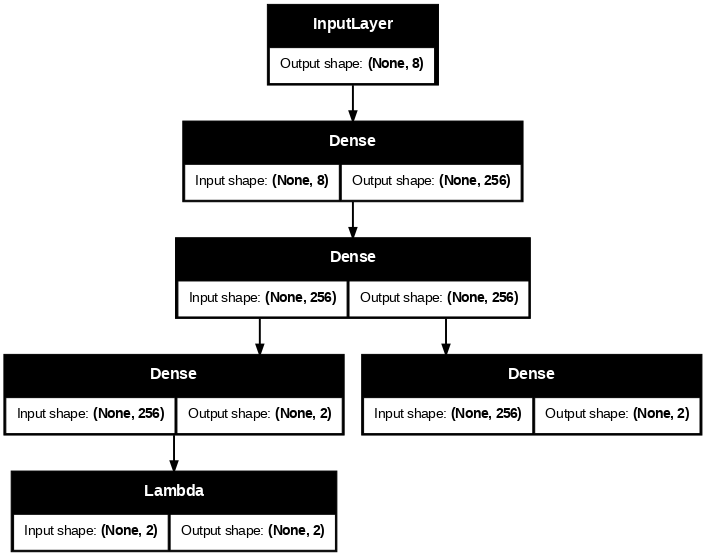

In [ ]:
def Actor(nodes=256):
    state = keras.Input((num_states,))
    x = Dense(nodes,'relu')(state)
#    x = BatchNormalization()(x)
    x = Dense(nodes,'relu')(x)
    mean = Dense(num_actions,'linear',name="mean")(x)
    log_sigma = Dense(num_actions,'linear',name="sigma")(x)
#    sigma = Lambda(lambda x: tf.clip_by_value(x, 1e-6, 1))(sigma)
    sigma = Lambda(lambda x: tf.exp(x))(log_sigma)
    return Model(state,[mean,sigma])

_actor = Actor(nodes=256)
_actor.summary()
keras.utils.plot_model(_actor, show_shapes=True,dpi=70)

## Critic Net

In [ ]:
def Critic(nodes=256):
    state = keras.Input((num_states,),name='state')
    action = keras.Input((num_actions,),name='action')
    x = Concatenate()([state,action])
    x = Dense(nodes,'relu')(x)
#    x = BatchNormalization()(x)
    x = Dense(nodes,'relu')(x)
    x = Dense(1,'linear',name='Qvalue')(x)
    return Model([state,action],x)

_critic = Critic(nodes=256)

Model: "functional_110"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ state (InputLayer)        │ (None, 8)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ action (InputLayer)       │ (None, 2)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_86            │ (None, 10)             │              0 │ state[0][0],           │
│ (Concatenate)             │                        │                │ action[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_220 (Dense)         │ (None, 256)            │          2,816 │ concatenate_86[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_221 (Dense)         │ (None, 256)            │         65,792 │ dense_220[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Qvalue (Dense)            │ (None, 1)              │            257 │ dense_221[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 68,865 (269.00 KB)

 Trainable params: 68,865 (269.00 KB)

 Non-trainable params: 0 (0.00 B)

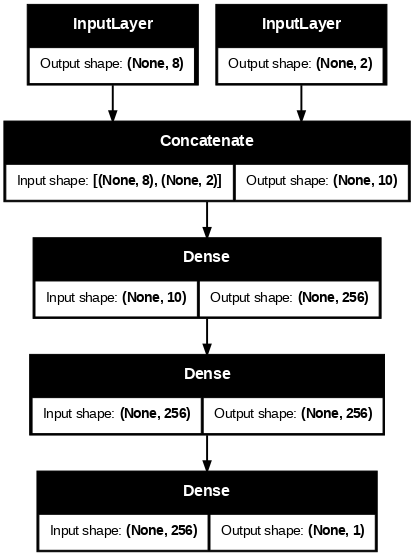

In [ ]:
_critic.summary()
keras.utils.plot_model(_critic, show_shapes=True,dpi=70)

In [ ]:
mu = [0.0, 0.5]     # 각 확률변수의 평균 벡터
sigma = [1.0, 2.0]  # 대각 공분산,diagonal covariance(표준 편차 벡터)

# MultivariateNormalDiag 분포 생성
mvn = tfp.distributions.Normal(loc=mu, scale_diag=sigma)

# 확률 변수 샘플링
samples = mvn.sample(2)          #(samples,2)
print('samples:\n',samples.numpy())

NameError: name 'tfp' is not defined

## Agnet

In [ ]:
@keras.saving.register_keras_serializable()
class Agent(keras.Model):
  def __init__(self,n_RM=100_000,env=env,nodes=256,batch_size=256,alpha=0.2,
                tau=0.005,Q_lr=3e-4,policy_lr=3e-4,alpha_lr=3e-4,gamma=0.99,*args,**kwargs):
    super(Agent, self).__init__(*args, **kwargs)
    self.env = env
    self.steps = 0
    self.total_scores = []
#    self.losses = []
    self.batch_size = batch_size
    self.tau = tau
    self.gamma = gamma
    self.RM = RBuffer(n_RM)

    self.actor = Actor(nodes)
    self.Q1 = Critic(nodes)
    self.Q2 = Critic(nodes)
    self.target_Q1 = Critic(nodes)
    self.target_Q2 = Critic(nodes)
    self.target_Q1.set_weights(self.Q1.get_weights())
    self.target_Q2.set_weights(self.Q2.get_weights())
#    self.alpha = tf.Variable(alpha,dtype=tf.float32) # for alpha learning
    self.alpha = 0  ##
    self.log_alpha = tf.Variable(tf.math.log(alpha), dtype=tf.float32) ##
    self.entropy_target = tf.constant(-self.env.action_space.shape[0],dtype=tf.float32) #-2

    self.Q1_optimizer = tf.keras.optimizers.Adam(Q_lr)
    self.Q2_optimizer = tf.keras.optimizers.Adam(Q_lr)
    self.actor_optimizer = tf.keras.optimizers.Adam(policy_lr)
    self.alpha_optimizer = tf.keras.optimizers.Adam(alpha_lr)

  @tf.function
  def sample_action(self, state, epsilon=1e-6 ):
#    print("sampling")
    mean, sigma = self.actor(state) # (bs,2),(bs,2)
    normal = tfp.distributions.Normal(mean, sigma)
    actions = normal.sample()      # u ~ mu(u|s) #(bs,2)
    action = tf.math.tanh(actions) # a = tanh(u) #(bs,2)
    action = tf.math.scalar_mul(tf.constant(1, dtype=tf.float32), action)
    action = tf.squeeze(action,)
    log_pi = normal.log_prob(actions)
    log_pi -= tf.math.log(1 - tf.math.square(action) + epsilon)
#    log_pi = tf.reduce_sum(log_pi,axis=1)
    log_pi = tf.reduce_sum(log_pi,axis=-1)
    return action, log_pi #(bs,2),(1,1)

  @tf.function
  def learn(self, states, actions, rewards, next_states, Ndones):
#    print("learn")
    with tf.GradientTape(persistent=True) as tape :
      next_actions, next_log_pi = self.sample_action(next_states) #(bs,2),(bs,)
      next_tQ1 = self.target_Q1([next_states, next_actions]) # Q1'(s',pi(s'))->(bs,1)
      next_tQ2 = self.target_Q2([next_states, next_actions])
      next_tQ_min = tf.minimum(next_tQ1, next_tQ2) - self.alpha * next_log_pi # min double Q + entropy
      tQ_y = rewards + Ndones * self.gamma * next_tQ_min # get y(r,s',a')
      ## training Q1,Q2 Net
      curr_Q1 = self.Q1([states, actions])                # Q1(s,a)
      curr_Q2 = self.Q2([states, actions])
      loss_Q1 = 0.5* tf.reduce_mean((tQ_y - curr_Q1)**2) # mean(y-Q1)^2
      loss_Q2 = 0.5* tf.reduce_mean((tQ_y - curr_Q2)**2) # mean(y-Q2)^2
      loss_Q = loss_Q1 + loss_Q2
      ## training actor Net
      predicted_actions, predicted_log_pi = self.sample_action(states) #(bs,2),(bs,)
      Q1_predicted = self.Q1([states, predicted_actions],)   #(bs,1) <- (bs,8)(bs,1)
      Q2_predicted = self.Q2([states, predicted_actions])
      Q_target = tf.minimum(Q1_predicted, Q2_predicted)     #(bs,1) minQ(s,a)
      actor_loss = -tf.reduce_mean(Q_target - self.alpha*predicted_log_pi)
      # training alpha
#      alpha_loss = tf.reduce_mean(self.alpha * (-predicted_log_pi - self.entropy_target))
      self.alpha = tf.exp(self.log_alpha) ##
      alpha_loss = tf.reduce_mean(self.log_alpha * (-predicted_log_pi - self.entropy_target))##


      Q1_gradient = tape.gradient(loss_Q1, self.Q1.trainable_variables)
      Q2_gradient = tape.gradient(loss_Q2, self.Q2.trainable_variables)
      actor_gradient = tape.gradient(actor_loss, self.actor.trainable_variables)
#      alpha_gradient = tape.gradient(alpha_loss, [self.alpha])
      alpha_gradient = tape.gradient(alpha_loss, [self.log_alpha])  ##

      self.Q1_optimizer.apply_gradients(zip(Q1_gradient, self.Q1.trainable_variables))
      self.Q2_optimizer.apply_gradients(zip(Q2_gradient, self.Q2.trainable_variables))
      self.actor_optimizer.apply_gradients(zip(actor_gradient, self.actor.trainable_variables))
#      self.alpha_optimizer.apply_gradients(zip(alpha_gradient, [self.alpha]))
      self.alpha_optimizer.apply_gradients(zip(alpha_gradient, [self.log_alpha])) ##

      # Update Q_target Net
      self.update_target(self.target_Q1, self.Q1)
      self.update_target(self.target_Q2, self.Q2)
      return loss_Q, actor_loss, alpha_loss, tf.reduce_mean(predicted_log_pi),-tf.reduce_mean(Q_target)

  # Soft Update
#   @tf.function
#   def update_target(self, target_weights, weights):
# #    print("update")
#     for (a, b) in zip(target_weights, weights):
#       a.assign(b * self.tau + a * (1 - self.tau))

  @tf.function
  def update_target(self, target_model, source_model):
      for target_var, source_var in zip(target_model.trainable_variables,\
                                        source_model.trainable_variables):
          target_var.assign(self.tau * source_var + (1 - self.tau) * target_var)

  # @tf.function
  # def update_target(self, target_model, source_model):
  #     new_weights = []
  #     for target_weights, source_weights in zip(target_model.get_weights(), source_model.get_weights()):
  #         new_weights.append(self.tau * source_weights + (1 - self.tau) * target_weights)
  #     target_model.set_weights(new_weights)

## Training

In [ ]:
nodes= 256
batch_size = 256 #128 #256 #256

epiosods = 150 #1000
#max_steps = 600

multi_update = 2
update_every = 1
update_after = batch_size  #1000
warmup = 200 #0

ep_rewards = []
avg_rewards = []
total_avgr_best = 50
losses = [[0,0,0,0,0]]
n_RM = 100_000 #20000

alpha=0.2 #0.2
tau= 1 #0.001 #0.005
Q_lr=0.002 #3e-4
policy_lr=0.0001 #3e-4
alpha_lr=0.0001 #3e-4
gamma=0.99

entorypy_target_schedule = True

In [ ]:
%%time
env= gym.make("LunarLanderContinuous-v2")
agent = Agent(n_RM=n_RM,env=env, nodes=nodes, batch_size=batch_size, alpha=alpha,
              tau=tau, gamma=gamma, Q_lr=Q_lr, policy_lr=policy_lr, alpha_lr=alpha_lr)

tot_steps = 0
epiosods = 10 #1000 #########
total_avgr_best = -300

for epis in range(epiosods):
  ep_step = 0
  ep_reward = 0
  done = False
  state = env.reset()
  while (not done) :# and (ep_step < max_steps) :
    action, log_pi = agent.sample_action(state[tf.newaxis,...])
    next_state, reward, done, info = env.step(action)
    agent.RM.record(state, action, reward, next_state, done)
    state = next_state
    ep_reward += reward
    ep_step += 1
    tot_steps += 1
    if agent.RM.cnt > batch_size:
      for _ in range(multi_update):
        states, actions, rewards, next_states, Ndones = agent.RM.sample(batch_size)
        losses.append(agent.learn(states, actions, rewards, next_states, Ndones))
    if done:
        ep_rewards.append(ep_reward)
        avg_rewards.append(np.mean(ep_rewards[-30:]))
        print(f"Episodes(steps):{epis:03d}({ep_step:03d}), Rewards(average):{ep_reward:3.1f}({avg_rewards[-1]:3.1f})",end="")
        last_losses = losses[-1]
        print(f',\t Loss:: Q:{last_losses[0]:.3f}, actor:{last_losses[1]:.3f}, alpha:{last_losses[2]:.5f}, ',end="")
        print(f'-log_pi:{last_losses[3]:.3f}, -Q_target:{last_losses[4]:.3f}), ent_target:{agent.entropy_target:.3f}',end="")
        print(f',\t Buffer.cnt:{agent.RM.cnt}')
    if entorypy_target_schedule :
      agent.entropy_target -= agent.entropy_target/(epiosods-epis)/30
  if total_avgr_best < avg_rewards[-1] :
    total_avgr_best = avg_rewards[-1]
    agent.save(path+"models/DRL/SoftAC_V2.keras")
    print(f'Model Saved.')
  if avg_rewards[-1] > 100: break #150

agent = keras.models.load_model(path+"models/DRL/SoftAC_V2.keras")
env.close()

Episodes(steps):000(172), Rewards(average):-276.2(-276.2),	 Loss:: Q:0.000, actor:0.000, alpha:0.00000, -log_pi:0.000, -Q_target:0.000), ent_target:-1.130,	 Buffer.cnt:172
Model Saved.
Episodes(steps):001(107), Rewards(average):-369.0(-322.6),	 Loss:: Q:24.218, actor:25.369, alpha:0.04382, -log_pi:0.610, -Q_target:25.245), ent_target:-0.760,	 Buffer.cnt:279
Episodes(steps):002(099), Rewards(average):-334.4(-326.5),	 Loss:: Q:18.539, actor:70.088, alpha:0.10138, -log_pi:0.322, -Q_target:70.023), ent_target:-0.503,	 Buffer.cnt:378
Episodes(steps):003(065), Rewards(average):-115.9(-273.9),	 Loss:: Q:9.469, actor:97.260, alpha:0.13382, -log_pi:0.148, -Q_target:97.230), ent_target:-0.369,	 Buffer.cnt:443
Model Saved.
Episodes(steps):004(082), Rewards(average):-95.2(-238.1),	 Loss:: Q:24.092, actor:118.258, alpha:0.14699, -log_pi:0.054, -Q_target:118.247), ent_target:-0.234,	 Buffer.cnt:525
Model Saved.
Episodes(steps):005(062), Rewards(average):-127.7(-219.7),	 Loss:: Q:1966.883, actor:322.

In [ ]:
%%time
env= gym.make("LunarLanderContinuous-v2")
agent = Agent(n_RM=n_RM, nodes=nodes, batch_size=batch_size, alpha=alpha,
              tau=tau, gamma=gamma, Q_lr=Q_lr, policy_lr=policy_lr, alpha_lr=alpha_lr)

epiosods = 150 #1000
tot_steps = 0
total_avgr_best = -300

for epis in range(epiosods):
  ep_step = 0
  ep_reward = 0
  done = False
  state = env.reset()
  while (not done) :# and (ep_step < max_steps) :
    action, log_pi = agent.sample_action(state[tf.newaxis,...])
    next_state, reward, done, info = env.step(action)
    agent.RM.record(state, action, reward, next_state, done)
    state = next_state
    ep_reward += reward
    ep_step += 1
    tot_steps += 1
    if agent.RM.cnt > batch_size:
      for _ in range(multi_update):
        states, actions, rewards, next_states, Ndones = agent.RM.sample(batch_size)
        losses.append(agent.learn(states, actions, rewards, next_states, Ndones))
    if done:
        ep_rewards.append(ep_reward)
        avg_rewards.append(np.mean(ep_rewards[-30:]))
        print(f"Episodes(steps):{epis:03d}({ep_step:03d}), Rewards(average):{ep_reward:3.1f}({avg_rewards[-1]:3.1f})",end="")
        last_losses = losses[-1]
        print(f',\t Loss:: Q:{last_losses[0]:.3f}, actor:{last_losses[1]:.3f}, alpha:{last_losses[2]:.5f}, ',end="")
        print(f'-log_pi:{last_losses[3]:.3f}, -Q_target:{last_losses[4]:.3f}), ent_target:{agent.entropy_target:.3f}',end="")
        print(f',\t Buffer.cnt:{agent.RM.cnt}')
    if entorypy_target_schedule :
      agent.entropy_target -= agent.entropy_target/(epiosods-epis)/30
  if total_avgr_best < avg_rewards[-1] :
    total_avgr_best = avg_rewards[-1]
    agent.save(path+"models/DRL/SoftAC_V2.keras")
    print(f'Model Saved.')
  if avg_rewards[-1] > 100: break #150

agent = keras.models.load_model(path+"models/DRL/SoftAC_V2.keras")
env.close()

Episodes(steps):000(105), Rewards(average):-229.0(-546.8),	 Loss:: Q:621893.250, actor:2792.440, alpha:-3.86829, -log_pi:12.372, -Q_target:2788.295), ent_target:-1.954,	 Buffer.cnt:105
Episodes(steps):001(065), Rewards(average):-131.6(-512.2),	 Loss:: Q:621893.250, actor:2792.440, alpha:-3.86829, -log_pi:12.372, -Q_target:2788.295), ent_target:-1.926,	 Buffer.cnt:170
Episodes(steps):002(084), Rewards(average):-176.2(-486.4),	 Loss:: Q:621893.250, actor:2792.440, alpha:-3.86829, -log_pi:12.372, -Q_target:2788.295), ent_target:-1.890,	 Buffer.cnt:254
Episodes(steps):003(109), Rewards(average):-399.7(-480.2),	 Loss:: Q:19.614, actor:74.921, alpha:0.41663, -log_pi:-0.419, -Q_target:74.996), ent_target:-1.844,	 Buffer.cnt:363
Episodes(steps):004(063), Rewards(average):21.5(-446.7),	 Loss:: Q:78.900, actor:109.724, alpha:0.26422, -log_pi:0.328, -Q_target:109.668), ent_target:-1.818,	 Buffer.cnt:426
Episodes(steps):005(151), Rewards(average):-427.9(-445.6),	 Loss:: Q:255.625, actor:20.088, al

Wall time: 24min 12s  
Wall time: 1h 7min 13s



In [ ]:
np_losses = np.array(losses)
def ma(a, n=10):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

Episodes(steps):099(67)
Wall time: 3min 33s

## Evaluation

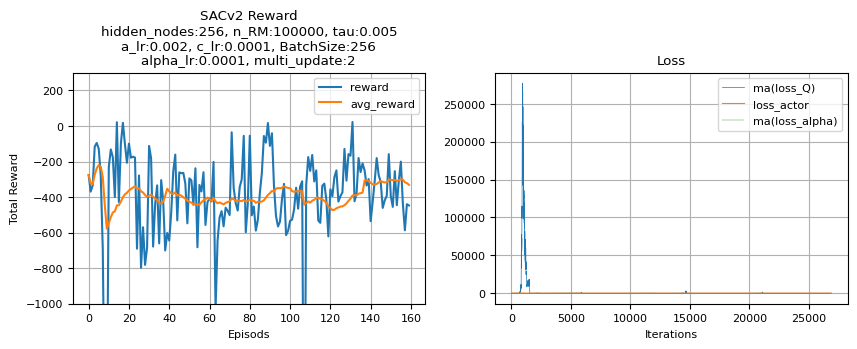

In [ ]:
conditions = f'hidden_nodes:{nodes}, n_RM:{n_RM}, tau:{agent.tau}\n\
a_lr:{Q_lr}, c_lr:{policy_lr}, BatchSize:{batch_size}\n\
alpha_lr:{alpha_lr}, multi_update:{multi_update}'

plt.figure(figsize=(10,3))
plt.subplot(121)
plt.title(f"SACv2 Reward\n{conditions}")

plt.plot(ep_rewards,label='reward')
plt.plot(avg_rewards ,label='avg_reward')
plt.xlabel("Episods")
plt.ylabel("Total Reward")
plt.ylim(-1000,300)
plt.grid()
plt.legend()

plt.subplot(122)
plt.plot(ma(np_losses[:,0]-100)/100,label='ma(loss_Q)',linewidth=0.5)
plt.plot(np_losses[:,1]/100,label='loss_actor',linewidth=0.8)
plt.plot(ma(np_losses[:,2],100),label='ma(loss_alpha)',linewidth=0.3)
#plt.plot(ma((np_losses[:,0]-100)/100+np_losses[:,1]/100,100),label='Q+A loss',linewidth=0.3)
#plt.plot(ma(np_losses[:,3],100)-2,label='log_pi',linewidth=0.8)
plt.title("Loss")
plt.xlabel("Iterations")
#plt.ylim(-1.1,1.7)
plt.grid()
plt.legend()
plt.show()
plt.show()

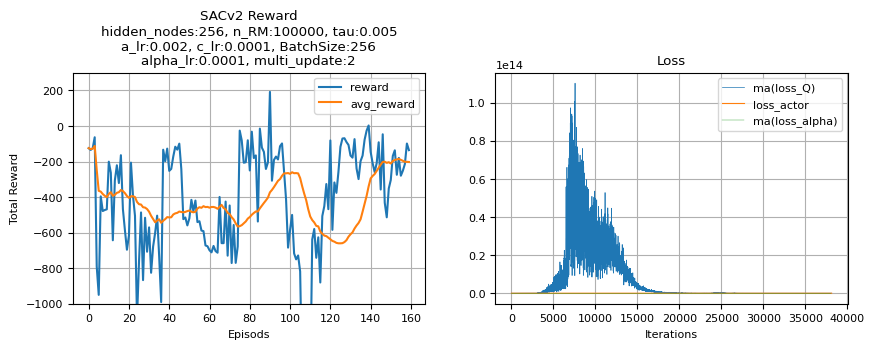

hidden_nodes:256, n_RM:100000, tau:0.001,         a_lr:0.0002, c_lr:0.0001, alpha_lr:0.0001, BatchSize:128, , multi_update:2  
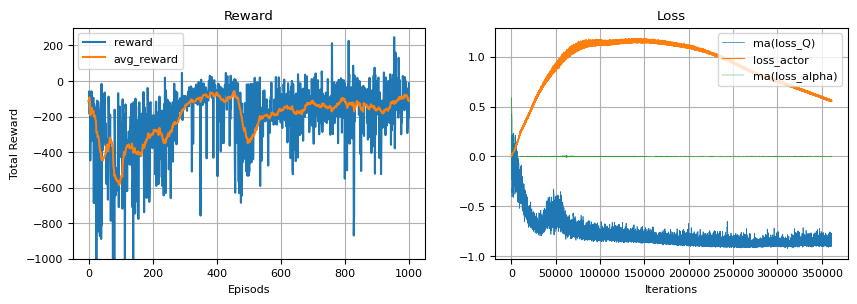


episodes = 2000   
hidden_nodes:128, n_RM:100000, tau:0.005,         a_lr:0.0001, c_lr:0.0001, alpha_lr:0.0003, BatchSize:256, , multi_update:1
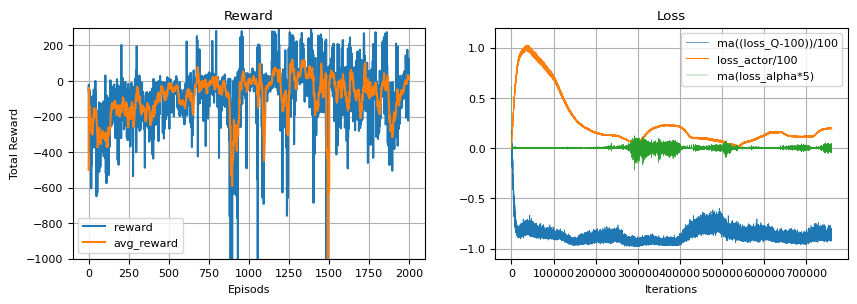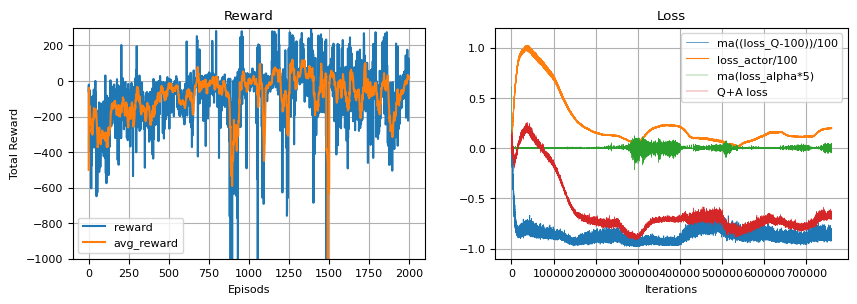

multi_update:2  
hidden_nodes:128, n_RM:100000, tau:0.005,         a_lr:0.0001, c_lr:0.0001, alpha_lr:0.0003, BatchSize:256   
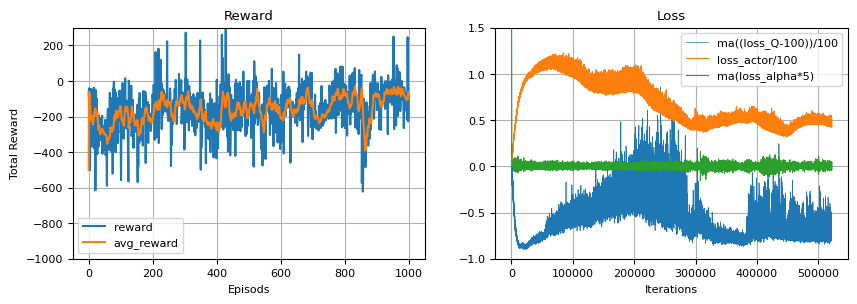


n_RM:100000  
hidden_nodes:128, tau:0.005,         a_lr:0.0001, c_lr:0.0001, alpha_lr:0.0003, BatchSize:128, , multi_update:1
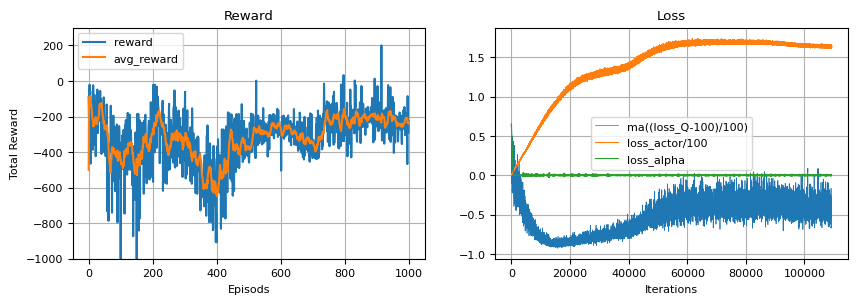


hidden_nodes:128   
n_RM:40000, tau:0.005,         a_lr:0.0001, c_lr:0.0001, alpha_lr:0.0003, BatchSize:128, , multi_update:1
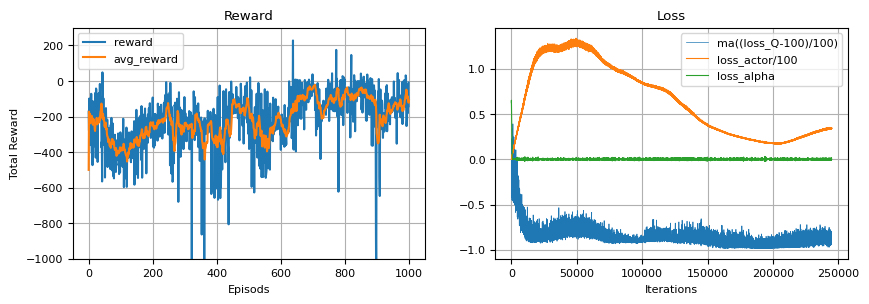

n_RM:40000  
hidden_nodes:256, tau:0.005,         a_lr:0.0001, c_lr:0.0001, alpha_lr:0.0003, BatchSize:128, , multi_update:1
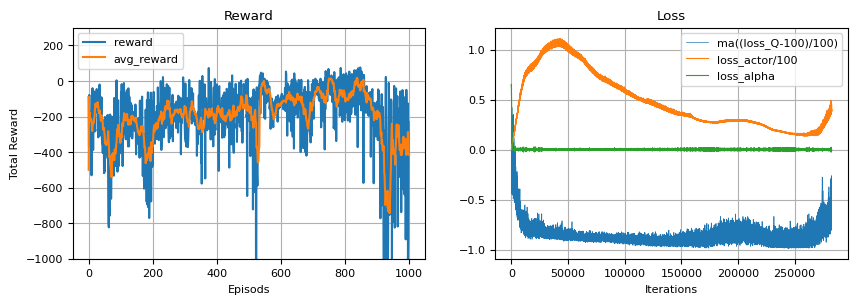

hidden_nodes:256, n_RBuffer:20000, tau:0.005,         a_lr:0.0003, c_lr:0.0003, alpha_lr:0.0003, BatchSize:128, , multi_update:1  
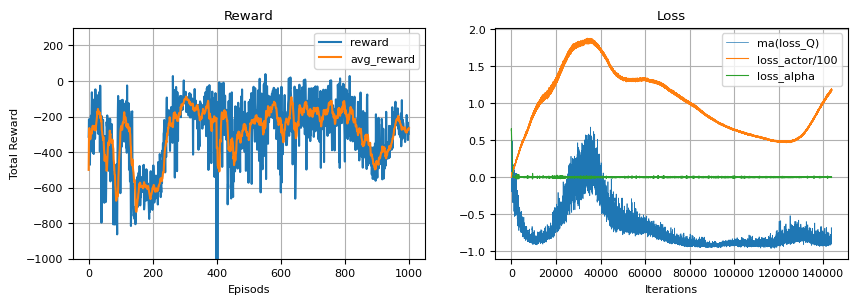


 multi_update:2     
hidden_nodes:256, n_RBuffer:20000, tau:0.005,         a_lr:0.0003, c_lr:0.0003, alpha_lr:0.0003, BatchSize:128
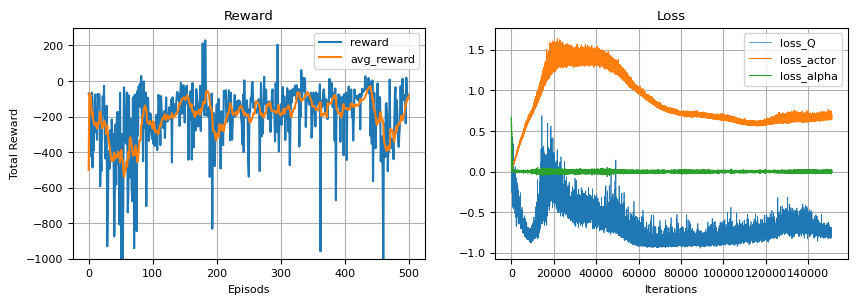


hidden_nodes:256, n_RBuffer:20000, tau:0.005,         a_lr:0.0003, c_lr:0.0003, alpha_lr:0.0003, BatchSize:128  
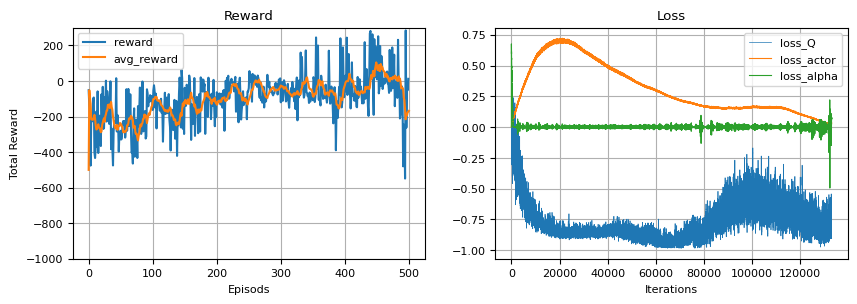


In [ ]:
agent = keras.models.load_model(path+"models/DRL/SoftAC_V2.keras")

In [ ]:
total_reward = 0
state = env.reset()
done = False
while not done:
    action, log_pi = agent.sample_action(state[tf.newaxis,...])
    next_state, reward, done, info = env.step(action)
    state = next_state
    total_reward += reward
    if done:
       print(total_reward)

-150.9325309588343


In [ ]:
%%capture
!pip install gym pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [ ]:
from render import  show_video, wrap_env, render_as_image

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
show_video(path=path,name_prefix='SACv2-LundarLander')

/content/gdrive/MyDrive/Colab Notebooks/video/SAC-LundarLander-episode-1.mp4
